# Compressed Image Classification
In this notebook, a Image Classification model is implemented, analyzing its performance over a dataset of compressed images. The aim of that is trying to make a prediction model able to classify images, starting from their compressed representation.

The idea is to use the ResNet50 model (the same used as baseline on raw images dataset), modifying it according to the new input size.

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms # Added import for transforms

# setup the device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# 1. The dataset
The CIFAR-10 dataset is a collection of images that are used to train machine learning and computer vision algorithms. It consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

### Compressed dataset
The compression made is based on Generalized Deduplication method, specifically using the EntroGD version. This lossless compression allows to obtain a deduplication of the so called "`bases`", that are the bits of a pixel containing part of information. A pixel is reconstructed using the associated base and the associated `deviation`.

For a better understanding, it can be imagined that the bases contain the low frequencies of the image, while the deviations are the high frequencies (the small details).

Moreover, the compressed file contains the `IDs` for identify uniquely each base, and so to connect each deviation to its respective base; and the `Counts`, counting how many times a base has been used

From the compressed version, it has been generated a .npz file containing the following information:
- (EXCLUDED FOR NOW) `base_max_bits` and `base_max_bits` are the integers corresponding to the highest and lowest bases, respectively
- `spatial_delta` is a spatial representation of the deltas, obtained after an ascending ordering of the bases. The values has then been normalized with a logarithmic transform, to obtain a representation between 0 and 1, for stability purposes. In particular, the log has been used to make the normalization robust to different magnitude deltas (i.e. `delta[0] = 3`; `delta[1] = 100000`). Finally, the data are mapped in a range [0,255] to represent them as `uint8`
- `spatial_rank_normalized` is a spatial representation of the ranks, that are the IDs re-assigned after the ascending ordering. These values has been normalized as well, simply by dividing each value by the maximum rank. This information helps to keep a reasonable meaning of the deltas, when they are mapped from the ascending order to the spatial representation. Same mapping to [0,255] for a `uint8` representation

### 1.1 Size of a single image
A single image will then consist of a one channel with 224x224 elements each. The new input dimension is around 2/3 wrt the raw image, since two channels has been removed, but the single channel we are considering contains `uint16` values rather than the previous `uint8` (~150k byte vs ~100k byte)

In [ ]:
# Inspection is performed after mounting Drive and loading the manifests below.
# No standalone image_00000.network.npz is required in Colab's working directory.


### 1.1 Dataset Download
The dataset has been downloaded on Google Drive, to make the retrieval faster among different sessions

In [ ]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')
DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/v2_cumulative_rank_s1/subsample")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class CumulativeDataset(Dataset):
    def __init__(self, manifest_path, transform=None):
        self.manifest_path = Path(manifest_path)
        self.folder = self.manifest_path.parent
        self.transform = transform

        with self.manifest_path.open(encoding="utf-8") as f:
            manifest = json.load(f)

        self.samples = manifest["samples"]
        self.idx_to_class = {
            index: name
            for name, index in manifest["class_to_idx"].items()
        }

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]

        with np.load(
            self.folder / sample["file"],
            allow_pickle=False
        ) as data:
            array = data["z_u16"].astype(np.float32)

        image = torch.from_numpy(array).unsqueeze(0)
        # shape: [1, 224, 224]

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, label

In [ ]:
# TRANSFORMS MUST BE WRITTEN HERE
# Statistics use ONLY the training manifest, before random augmentation.
# CumulativeDataset already returns float32 tensors [1, 224, 224] in raw z units.
import hashlib
import json
import numpy as np

TRAIN_MANIFEST = DATA_ROOT / "train" / "subsample_manifest_train.json"
TEST_MANIFEST = DATA_ROOT / "test" / "subsample_manifest_test.json"
STATS_PATH = TRAIN_MANIFEST.parent / "normalization_z_u16.json"
FORCE_RECOMPUTE_STATS = False  # Set True after replacing data while preserving file timestamps.


def training_stats(manifest_path, cache_path, force=False):
    """Compute mean and variance on the training set, if they didn't exist yet. If so, it load them"""
    manifest_bytes = manifest_path.read_bytes()
    manifest = json.loads(manifest_bytes)
    if manifest.get("split") != "train":
        raise ValueError("Normalization statistics must come from the training split.")
    samples = manifest["samples"]
    if not samples:
        raise ValueError("The training manifest is empty.")
    filenames = [sample["file"] for sample in samples]
    if len(set(filenames)) != len(filenames):
        raise ValueError("Duplicate files in the training manifest.")

    # Invalidate cache when the manifest, file size, or modification time changes.
    # This avoids re-reading all arrays when re-running the notebook.
    signature = hashlib.sha256(b"z_u16-raw-224x224-population-std-v1\n")
    signature.update(manifest_bytes)
    paths = [manifest_path.parent / filename for filename in filenames]
    for path in paths:
        stat = path.stat()
        signature.update(f"{path.name}:{stat.st_size}:{stat.st_mtime_ns}\n".encode())
    fingerprint = signature.hexdigest()

    if cache_path.exists() and not force:
        cached = json.loads(cache_path.read_text(encoding="utf-8"))
        if cached.get("fingerprint") == fingerprint:
            if not np.isfinite(cached["mean"]) or not np.isfinite(cached["std"]) or cached["std"] <= 0:
                raise ValueError("Invalid cached statistics; set FORCE_RECOMPUTE_STATS=True.")
            print(f"Loaded training statistics from {cache_path}")
            return cached

    # Merge per-image moments in float64: global population std, not the
    # average of image standard deviations. Only one image is held at a time.
    count, mean, m2 = 0, 0.0, 0.0
    for index, path in enumerate(paths, 1):
        with np.load(path, allow_pickle=False) as archive:
            z = archive["z_u16"]
            if z.dtype != np.uint16 or z.shape != (224, 224):
                raise ValueError(f"Expected uint16 [224,224]: {path}, got {z.dtype} {z.shape}")
            values = z.astype(np.float64)
        n = values.size
        image_mean = float(values.mean())
        image_m2 = float(np.square(values - image_mean).sum())
        new_count = count + n
        delta = image_mean - mean
        m2 += image_m2 + delta * delta * count * n / new_count
        mean += delta * n / new_count
        count = new_count
        if index % 500 == 0 or index == len(paths):
            print(f"Training statistics: {index}/{len(paths)} images")

    std = float(np.sqrt(m2 / count))
    if not np.isfinite(std) or std <= 0:
        raise ValueError("Training standard deviation is zero or non-finite.")
    stats = dict(schema="z_u16-normalization-v1", fingerprint=fingerprint,
                 training_manifest=manifest_path.name, num_images=len(paths),
                 num_pixels=count, mean=float(mean), std=std,
                 units="raw z_u16 values; no division by 65535", ddof=0)
    temporary = cache_path.with_suffix(".json.tmp")
    temporary.write_text(json.dumps(stats, indent=2) + "\n", encoding="utf-8")
    temporary.replace(cache_path)
    print(f"Saved training statistics to {cache_path}")
    return stats


normalization_stats = training_stats(
    TRAIN_MANIFEST, STATS_PATH, force=FORCE_RECOMPUTE_STATS
)
CHANNEL_MEAN = normalization_stats["mean"]
CHANNEL_STD = normalization_stats["std"]
print(f"Training mean={CHANNEL_MEAN:.6f}, std={CHANNEL_STD:.6f} (raw z units)")

# Inputs are already tensors and 224x224; Resize is normally a no-op.
# Do not add ToTensor() or divide by 65535: the statistics are in raw z units.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Normalize(mean=[CHANNEL_MEAN], std=[CHANNEL_STD]),
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[CHANNEL_MEAN], std=[CHANNEL_STD]),
])


In [ ]:
train_data = CumulativeDataset(TRAIN_MANIFEST, transform=train_transform)
test_data = CumulativeDataset(TEST_MANIFEST, transform=test_transform)
assert train_data.idx_to_class == test_data.idx_to_class
print(f"Training samples: {len(train_data)}; test samples: {len(test_data)}")


#2. Batches generation and check their validity

In [ ]:
BATCH_SIZE = 32
train_generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          generator=train_generator, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_loader)} batches; test: {len(test_loader)} batches")

x, y = next(iter(train_loader))
print(f"Images: {x.shape}; labels: {y.shape}")
# These are feature maps, not reconstructed RGB images.
raw_maps = x * CHANNEL_STD + CHANNEL_MEAN
count = min(8, len(raw_maps))
fig, axes = plt.subplots(1, count, figsize=(2 * count, 3), squeeze=False)
vmax = max(float(raw_maps[:count].max()), 1.0)
for i, axis in enumerate(axes[0]):
    axis.imshow(raw_maps[i, 0].numpy(), cmap="gray", vmin=0, vmax=vmax)
    axis.set_title(train_data.idx_to_class[y[i].item()])
    axis.axis("off")
fig.suptitle("Cumulative-rank maps (shared display scale)")
plt.tight_layout()
plt.show()


Check batch validity:

Image shape: torch.Size([3, 224, 224])


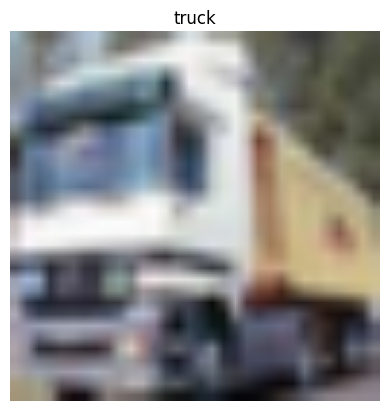

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)  # torch.Size([32, 1, 224, 224])
print(images.dtype)  # torch.float32

print(labels.shape) # torch.Size([32])
print(labels.dtype) # torch.int64
print(labels[:5])

print([
    train_data.idx_to_class[label.item()]
    for label in labels[:5]
])

#3. The Model: Pre-Trained ResNet50
In a first try, the ResNet50 model is used. At first, only a fine tuning of the last layer, for make the size compatible, is made

In [ ]:
# The one-channel model is defined and instantiated in the next code cells.
# Do not create a separate RGB model: optimizer, training and saving must use
# the same instance, named custom_resnet_model.


### Custom ResNet50 for single-channel input + additional features

We need to define a custom ResNet50 class that extends `torchvision.models.ResNet` to:

1.  **Modify the first convolutional layer (`conv1`)**: Change its `in_channels` from 3 (for RGB) to 2 (for `spatial_delta` and `spatial_rank`). When loading pre-trained weights, we'll exclude the original `conv1` weights and initialize the new `conv1` layer.
2.  **Modify the final fully connected layer (`fc`)**: This layer will need to accept `num_features_from_resnet_backbone + num_additional_scalar_features`. The ResNet50 backbone (before the `fc` layer) outputs 2048 features, so with 2 additional features, the new `fc` layer will take `2048 + 2 = 2050` input features.
3.  **Adjust the `forward` method**: The `forward` method will now accept two distinct inputs: the 2-channel image tensor and a tensor containing the additional scalar features. These will be concatenated before being fed into the final `fc` layer.

In [ ]:
import torchvision.models as models
import torch.nn as nn

class CustomResNet50(models.ResNet):
    def __init__(self, num_classes=10, pretrained=True):
        super().__init__(models.resnet.Bottleneck, [3, 4, 6, 3], num_classes=num_classes)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            weights = models.ResNet50_Weights.IMAGENET1K_V1
            state = weights.get_state_dict(progress=True)
            state = {k: v for k, v in state.items()
                     if not (k.startswith("conv1.") or k.startswith("fc."))}
            self.load_state_dict(state, strict=False)
        nn.init.kaiming_normal_(self.conv1.weight, mode="fan_out", nonlinearity="relu")
        # Preserve the chosen experiment: train only the new conv1 and fc.
        for parameter in self.parameters():
            parameter.requires_grad = False
        for layer in (self.conv1, self.fc):
            for parameter in layer.parameters():
                parameter.requires_grad = True

    def train(self, mode=True):
        super().train(mode)
        # requires_grad=False does not freeze BatchNorm running statistics.
        # Keep the frozen backbone statistics fixed as well.
        for module in self.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        return self
    # Inherit ResNet.forward: it already supports the replaced one-channel conv1.


In [ ]:
# Seed BEFORE initializing the new layers.
torch.manual_seed(42)
custom_resnet_model = CustomResNet50(num_classes=10).to(device)
print("Total parameters:", sum(p.numel() for p in custom_resnet_model.parameters()))
print("Trainable parameters:", sum(p.numel() for p in custom_resnet_model.parameters() if p.requires_grad))

# Small forward check, without updating BatchNorm statistics.
custom_resnet_model.eval()
with torch.inference_mode():
    check_logits = custom_resnet_model(images[:2].to(device))
assert check_logits.shape == (min(2, len(images)), 10)
assert torch.isfinite(check_logits).all()
print("Forward check:", check_logits.shape)


#4. Functions
Some functions helpful for repeated workflows

### 4.1 Training and testing

In [ ]:
def train_step(model, data_loader, loss_fn, optimizer, device=device):
    model.to(device)
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        # CrossEntropyLoss uses the batch mean; weight it by actual batch size.
        batch_size = y.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == y).sum().item()
        count += batch_size
    if count == 0:
        raise ValueError("Empty training loader")
    metrics = {"loss": loss_sum / count, "accuracy": 100.0 * correct / count}
    print(f"Train loss: {metrics['loss']:.5f} | Train accuracy: {metrics['accuracy']:.2f}%")
    return metrics


def test_step(model, data_loader, loss_fn, device=device):
    model.to(device)
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.inference_mode():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += loss_fn(logits, y).item() * y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            count += y.size(0)
    if count == 0:
        raise ValueError("Empty test loader")
    metrics = {"loss": loss_sum / count, "accuracy": 100.0 * correct / count}
    print(f"Test loss: {metrics['loss']:.5f} | Test accuracy: {metrics['accuracy']:.2f}%")
    return metrics


### 4.2 Timing function

In [8]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    # device ([type], optional): Device that compute is running on. Defaults to None.

    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 4.3 Accuracy Function


In [9]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

#5. Training and Test loops


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    (p for p in custom_resnet_model.parameters() if p.requires_grad), lr=0.1
)
# Fixed learning rate for this smoke experiment. A ReduceLROnPlateau scheduler
# requires a separate validation split; do not tune it on the test set.


In [ ]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

train_time_start_model = timer()
epochs = 5
history = []
for epoch in tqdm(range(epochs)):
    print(f"\nEpoch: {epoch + 1}/{epochs}")
    history.append(train_step(custom_resnet_model, train_loader, loss_fn, optimizer, device))

# Evaluate the held-out test only after training, without driving a scheduler.
test_metrics = test_step(custom_resnet_model, test_loader, loss_fn, device)
total_train_time_model = print_train_time(
    train_time_start_model, timer(), device=device
)


#6. Save and load the model
What we save of a model are its parameters so when we load it back we should create an instance of the model, then set as parameter values, the values we saved

In [ ]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "ResNet50_cumulative_rank_v2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
# A checkpoint includes preprocessing information as well as model weights.
torch.save({
    "model_state_dict": custom_resnet_model.state_dict(),
    "num_classes": 10,
    "normalization": normalization_stats,
    "idx_to_class": train_data.idx_to_class,
    "train_manifest": str(TRAIN_MANIFEST),
    "test_manifest": str(TEST_MANIFEST),
    "history": history,
    "test_metrics": test_metrics,
}, MODEL_SAVE_PATH)
print(f"Saved checkpoint: {MODEL_SAVE_PATH}")


### Loading the saved model

In [ ]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True)
# Rebuild exactly the saved architecture; no ImageNet download is needed here.
loaded_model = CustomResNet50(num_classes=checkpoint["num_classes"], pretrained=False).to(device)
loaded_model.load_state_dict(checkpoint["model_state_dict"], strict=True)
loaded_model.eval()
loaded_mean = checkpoint["normalization"]["mean"]
loaded_std = checkpoint["normalization"]["std"]
# Confirm the save/load round trip on the same preprocessed inputs.
custom_resnet_model.eval()
with torch.inference_mode():
    probe = images[:2].to(device)
    torch.testing.assert_close(loaded_model(probe), custom_resnet_model(probe))
print("Checkpoint restored; predictions match.")


### Saving the model to Google Drive

In [ ]:
import shutil

# Define the target directory on Google Drive
# Re-using 'data_dir' and creating a 'models' subdirectory within it
data_dir = '/content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/'
drive_models_dir = Path(data_dir) / "models"
drive_models_dir.mkdir(parents=True, exist_ok=True)

# Define the full path for saving the model on Google Drive
MODEL_SAVE_PATH_DRIVE = drive_models_dir / MODEL_NAME

# Copy the locally saved model to Google Drive
shutil.copy(MODEL_SAVE_PATH, MODEL_SAVE_PATH_DRIVE)

print(f"Model saved to Google Drive at: {MODEL_SAVE_PATH_DRIVE}")

Model saved to Google Drive at: /content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/models/ResNet50.pth
